<a href="https://colab.research.google.com/github/Sreyasanjai/ML/blob/main/lasso%20regression%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [8]:
diabetes=load_diabetes()
x=diabetes.data
y=diabetes.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
print("Traning samlples:",x_train.shape[0])
print("Testing samples:",x_test.shape[0])

Traning samlples: 353
Testing samples: 89


In [16]:
linear_model=LinearRegression()
linear_model.fit(x_train,y_train)
y_pred_linear = linear_model.predict(x_test)
print("Linear Regression:")
print("MSE="+str(mean_squared_error(y_test,y_pred_linear)))
print("R2 Score="+str(r2_score(y_test,y_pred_linear)))
ridge_model =Ridge()
param_grid ={'alpha':[0.01,0.1,1,100]}
ridge_cv =GridSearchCV(ridge_model,param_grid,cv=5)
ridge_cv.fit(x_train,y_train)
best_ridge_model =ridge_cv.best_estimator_
y_pred_ridge =best_ridge_model.predict(x_test)
print(f'Best Alpha for Ridge: {ridge_cv.best_params_['alpha']}')
print(f'MSE= {mean_squared_error(y_test,y_pred_ridge)}')
print(f'R2 Score= {r2_score(y_test,y_pred_ridge)}')
lasso=Lasso(max_iter=10000)
lasso_cv=GridSearchCV(lasso,param_grid,cv=5)
lasso_cv.fit(x_train,y_train)
best_lasso_model=lasso_cv.best_estimator_
y_pred_lasso=best_lasso_model.predict(x_test)
print(f'Best Alpha for Lasso: {lasso_cv.best_params_['alpha']}')
print(f'MSE= {mean_squared_error(y_test,y_pred_lasso)}')
print(f"R2 score: {r2_score(y_test,y_pred_lasso)}")
result = pd.DataFrame({
    'Model':['Linear Regression','Ridge Regression','Lasso Regression'],
    'MSE':[mean_squared_error(y_test,y_pred_linear),mean_squared_error(y_test,y_pred_ridge),mean_squared_error(y_test,y_pred_lasso)],
    'R2 Score':[r2_score(y_test,y_pred_linear),r2_score(y_test,y_pred_ridge),r2_score(y_test,y_pred_lasso)]
})
result

Linear Regression:
MSE=2900.1936284934823
R2 Score=0.45260276297191926
Best Alpha for Ridge: 1
MSE= 2892.0145657501726
R2 Score= 0.45414652070698225
Best Alpha for Lasso: 1
MSE= 2824.568094049959
R2 score: 0.46687670944102466


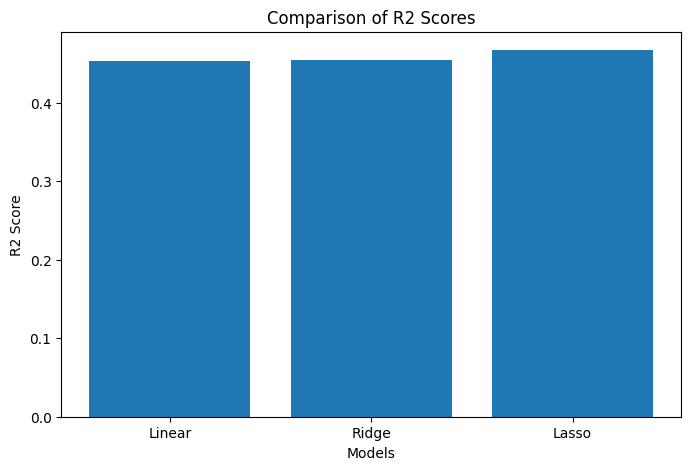

In [17]:
plt.figure(figsize=(8,5))
models = ['Linear','Ridge','Lasso']
r2_scores = [r2_score(y_test,y_pred_linear),r2_score(y_test,y_pred_ridge),r2_score(y_test,y_pred_lasso)]
plt.bar(models,r2_scores)
plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.title('Comparison of R2 Scores')
plt.show()